# Model Comparison — YOLOv8 vs YOLOv11

This notebook compares two licence-plate detection models head-to-head:

| | YOLOv8 | YOLOv11 |
|---|---|---|
| **File** | `models/yolov8n.pt` | `models/yolo11n.pt` |
| **Origin** | General-purpose COCO model | General-purpose COCO model |
| **Format** | PyTorch `.pt` | PyTorch `.pt` |

### What we compare
1. **Quantitative** — mAP@50, mAP@50:95, Precision, Recall on the validation split
2. **Visual** — side-by-side bounding boxes on the same images
3. **Confidence distribution** — how sure each model is about its detections
4. **Box quality** — IoU of each predicted box against the ground-truth label


## 1. Setup

In [6]:
%matplotlib inline

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import onnxruntime as ort   # must be imported before torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import yaml
import torch
from ultralytics import YOLO

# ── Model paths ───────────────────────────────────────────────────────────────
MY_MODEL_PATH  = Path("models/yolov8n.pt")
REF_MODEL_PATH = Path("models/yolo11n.pt")
DATASET_YAML   = Path("data-car-images/data.yaml")
DATASET_ROOT   = Path("data-car-images")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

# Verify both model files exist before continuing
assert MY_MODEL_PATH.exists(),  f"YOLOv8 model not found: {MY_MODEL_PATH}"
assert REF_MODEL_PATH.exists(), f"YOLOv11 model not found: {REF_MODEL_PATH}"

print(f"YOLOv8  : {MY_MODEL_PATH}")
print(f"YOLOv11 : {REF_MODEL_PATH}")


Device : cpu
YOLOv8  : models\yolov8n.pt
YOLOv11 : models\yolo11n.pt


In [7]:
# ── Load both models ──────────────────────────────────────────────────────────
my_model  = YOLO(str(MY_MODEL_PATH))
ref_model = YOLO(str(REF_MODEL_PATH))

print("YOLOv8  classes:", my_model.names)
print("YOLOv11 classes:", ref_model.names)


YOLOv8  classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell ph

## 2. Quantitative Evaluation — mAP, Precision, Recall

Both models are evaluated on the **same validation split** so the numbers are directly comparable.

- **Precision** — of all predicted boxes, how many were actually correct?
- **Recall** — of all real plates, how many did the model find?
- **mAP@50** — mean Average Precision at IoU ≥ 0.50 (the standard benchmark)
- **mAP@50:95** — stricter average across IoU thresholds 0.50 → 0.95 (used in COCO)


In [10]:
data_yaml = str(DATASET_YAML.resolve())

print("Evaluating YOLOv8 on validation split …")
my_val = my_model.val(data=data_yaml, split="val", device=device, verbose=False)

print("\nEvaluating YOLOv11 on validation split …")
ref_val = ref_model.val(data=data_yaml, split="val", device=device, verbose=False)

# ── Collect metrics into a comparison table ───────────────────────────────────
def extract_metrics(val_result, label: str) -> dict:
    b = val_result.box
    return {
        "Model":        label,
        "Precision":    round(float(b.mp),   4),
        "Recall":       round(float(b.mr),   4),
        "mAP@50":       round(float(b.map50),  4),
        "mAP@50:95":    round(float(b.map),    4),
    }

rows = [
    extract_metrics(my_val,  "YOLOv8"),
    extract_metrics(ref_val, "YOLOv11"),
]

df_metrics = pd.DataFrame(rows).set_index("Model")
print("\n" + "="*60)
print(df_metrics.to_string())
print("="*60)


Evaluating YOLOv8 on validation split …
Ultralytics 8.4.41  Python-3.13.7 torch-2.7.1+cpu CPU (AMD Ryzen 7 PRO 7840U w/ Radeon 780M Graphics)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 240.067.2 MB/s, size: 28.5 KB)
val: Scanning C:\Users\krist\Documents\GitHub\Object-Detection-Research\data-car-images\valid\labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.0it/s 0.5s
                   all         10         10          0          0          0          0
Speed: 0.9ms preprocess, 43.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to C:\Users\krist\Documents\GitHub\Object-Detection-Research\runs\detect\val-12

Evaluating YOLOv11 on validation split …
Ultralytics 8.4.41  Python-3.13.7 torch-2.7.1+cpu CPU (AMD Ryzen 7 PRO 7840U w/

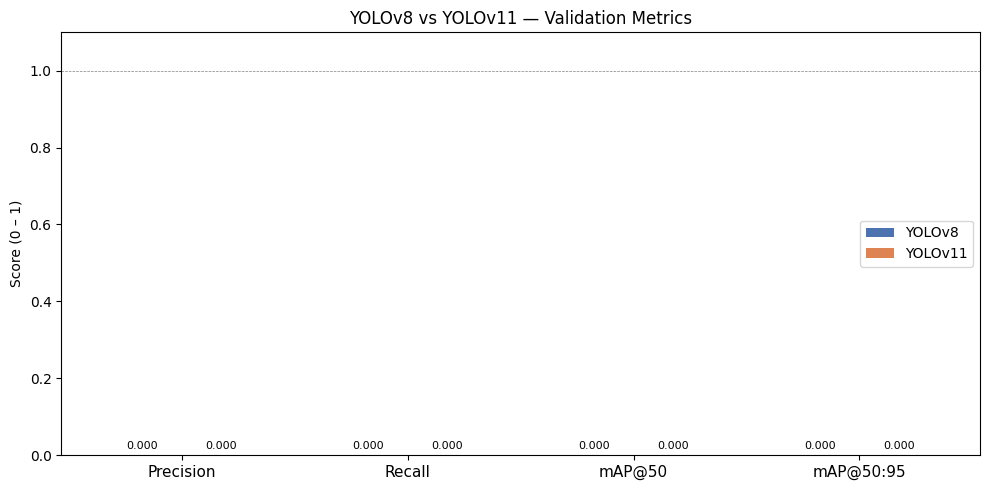

In [11]:
# ── Bar chart — metrics side by side ─────────────────────────────────────────
metrics_to_plot = ["Precision", "Recall", "mAP@50", "mAP@50:95"]
x     = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_my  = ax.bar(x - width/2, df_metrics.loc["YOLOv8",  metrics_to_plot], width, label="YOLOv8",  color="#4C72B0")
bars_ref = ax.bar(x + width/2, df_metrics.loc["YOLOv11", metrics_to_plot], width, label="YOLOv11", color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score (0 – 1)")
ax.set_title("YOLOv8 vs YOLOv11 — Validation Metrics")
ax.legend()
ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")

# Label each bar with its value
for bar in list(bars_my) + list(bars_ref):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


## 3. Visual Comparison — Side-by-Side on Validation Images

Each row shows the **same image** processed by both models.
- **Green** = ground-truth label
- **Blue** = My trained model prediction
- **Orange** = Pre-trained reference prediction


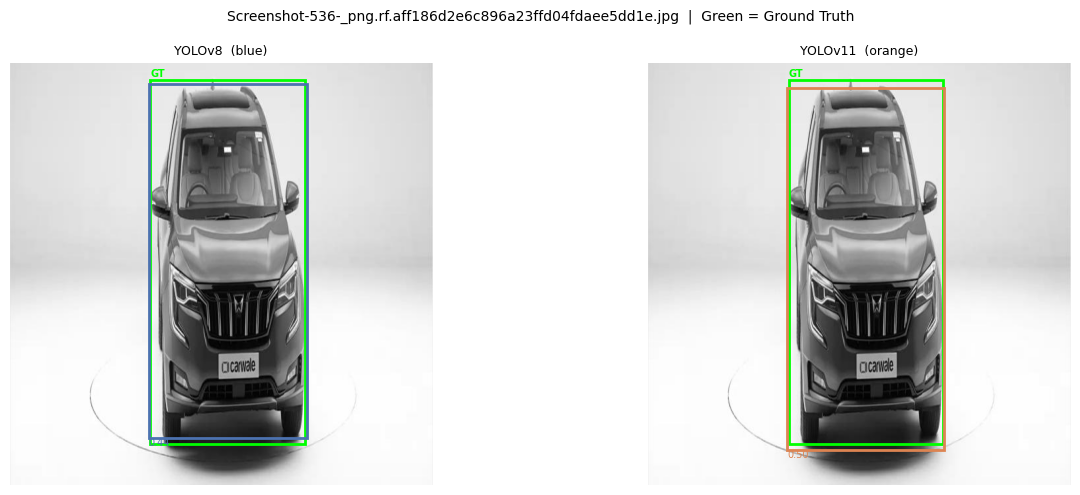

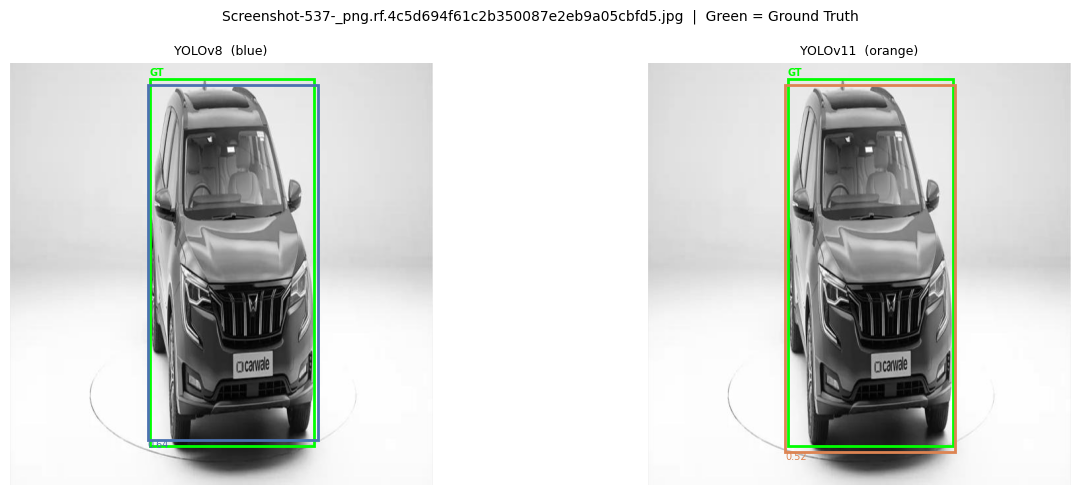

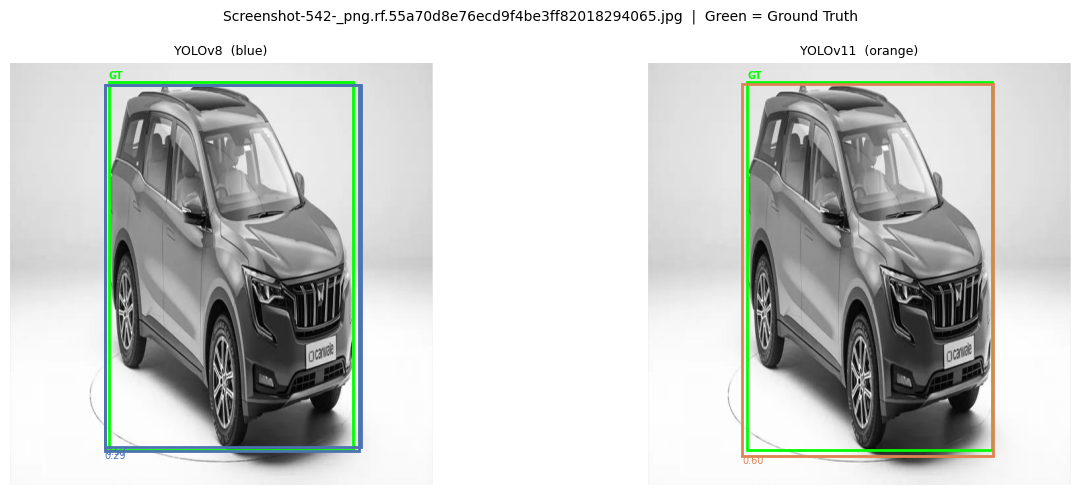

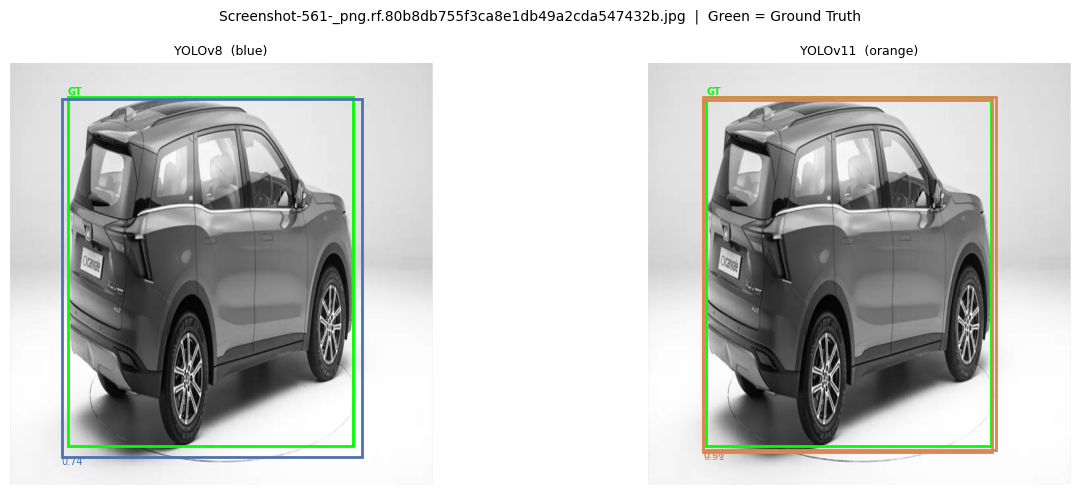

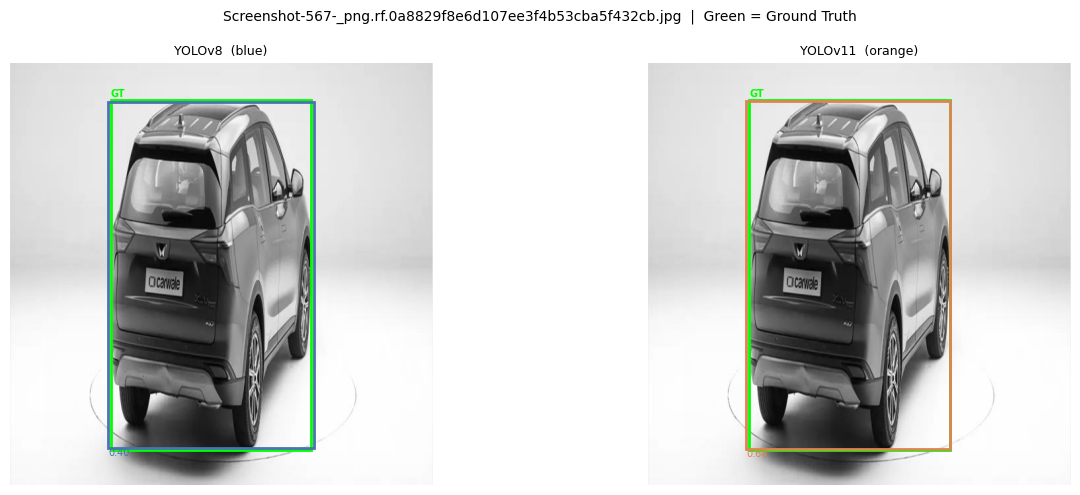

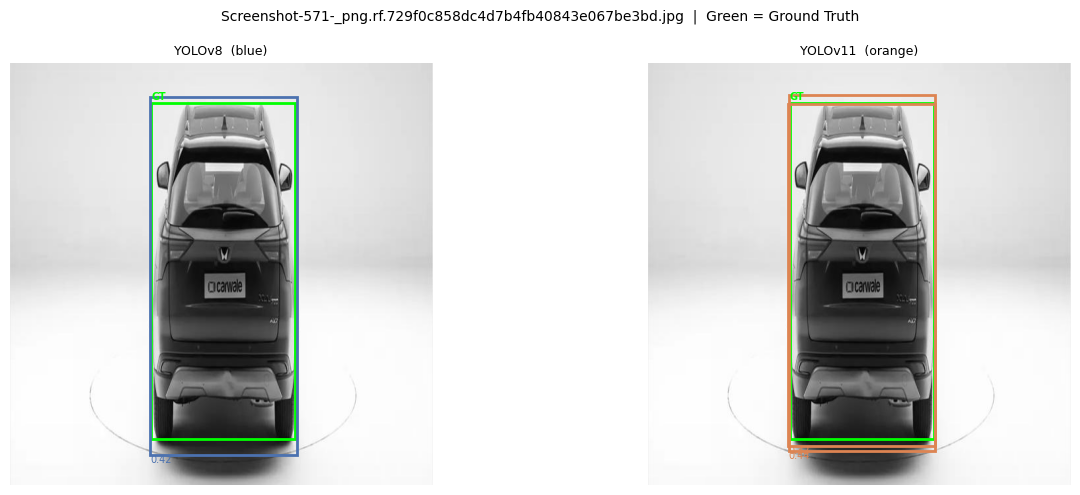

In [12]:
def parse_gt_boxes(label_path: Path, img_w: int, img_h: int) -> list:
    """Read YOLO label file → list of [x1,y1,x2,y2] pixel boxes."""
    if not label_path.exists():
        return []
    boxes = []
    for line in label_path.read_text().strip().splitlines():
        parts = list(map(float, line.split()))
        if len(parts) < 5:
            continue
        _, cx, cy, w, h = parts[:5]
        boxes.append([
            int((cx - w/2) * img_w), int((cy - h/2) * img_h),
            int((cx + w/2) * img_w), int((cy + h/2) * img_h),
        ])
    return boxes


def draw_boxes(ax, img_rgb, gt_boxes, pred_boxes, pred_color, model_label, conf=0.25):
    ax.imshow(img_rgb)
    for b in gt_boxes:
        ax.add_patch(patches.Rectangle(
            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
            linewidth=2, edgecolor="lime", facecolor="none"))
        ax.text(b[0], b[1]-4, "GT", color="lime", fontsize=7, fontweight="bold")
    for box in pred_boxes:
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        c = float(box.conf)
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=pred_color, facecolor="none"))
        ax.text(x1, y2+12, f"{c:.2f}", color=pred_color, fontsize=7)
    ax.set_title(model_label, fontsize=9)
    ax.axis("off")


# ── Run on up to 6 validation images ─────────────────────────────────────────
val_img_dir = DATASET_ROOT / "valid" / "images"
val_lbl_dir = DATASET_ROOT / "valid" / "labels"
val_imgs    = sorted(val_img_dir.glob("*.jpg"))[:6]

CONF = 0.25

for img_p in val_imgs:
    lbl_p   = val_lbl_dir / img_p.with_suffix(".txt").name
    img_bgr = cv2.imread(str(img_p))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    gt_boxes   = parse_gt_boxes(lbl_p, w, h)
    my_preds   = my_model.predict(str(img_p),  conf=CONF, verbose=False)[0].boxes
    ref_preds  = ref_model.predict(str(img_p), conf=CONF, verbose=False)[0].boxes

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    draw_boxes(ax1, img_rgb, gt_boxes, my_preds,  "#4C72B0", "YOLOv8  (blue)")
    draw_boxes(ax2, img_rgb, gt_boxes, ref_preds, "#DD8452", "YOLOv11  (orange)")
    plt.suptitle(f"{img_p.name}  |  Green = Ground Truth", fontsize=10)
    plt.tight_layout()
    plt.show()


## 4. Confidence Score Distribution

How confident is each model across all detections on the validation set?  
A well-trained model should cluster near **high confidence (> 0.7)** with few low-confidence detections.


YOLOv8  — 54  detections  |  mean conf: 0.150
YOLOv11 — 23 detections  |  mean conf: 0.368


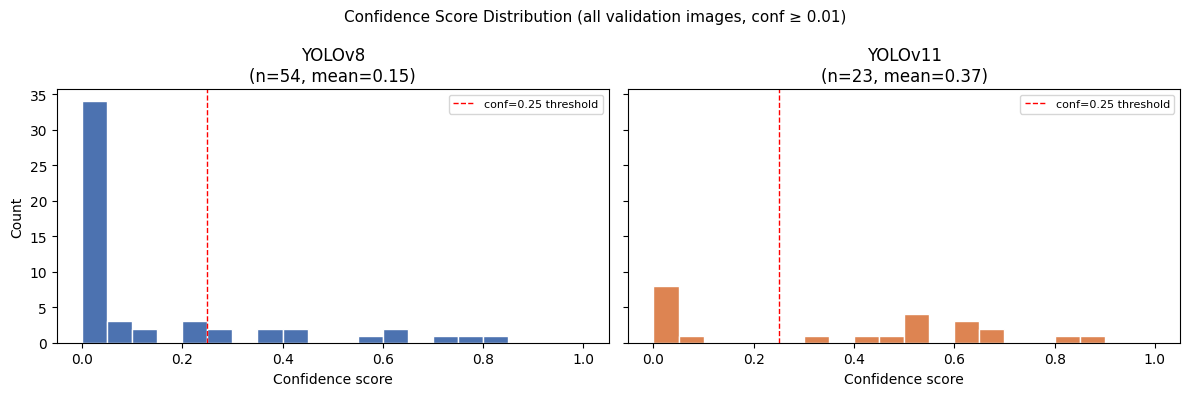

In [13]:
# ── Collect all confidence scores over the full validation set ────────────────
all_val_imgs = sorted(val_img_dir.glob("*.jpg"))

my_confs  = []
ref_confs = []

for img_p in all_val_imgs:
    my_boxes  = my_model.predict(str(img_p),  conf=0.01, verbose=False)[0].boxes
    ref_boxes = ref_model.predict(str(img_p), conf=0.01, verbose=False)[0].boxes
    my_confs  += [float(b.conf) for b in my_boxes]
    ref_confs += [float(b.conf) for b in ref_boxes]

print(f"YOLOv8  — {len(my_confs)}  detections  |  mean conf: {np.mean(my_confs):.3f}")
print(f"YOLOv11 — {len(ref_confs)} detections  |  mean conf: {np.mean(ref_confs):.3f}")

# ── Histogram ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(my_confs,  bins=20, range=(0,1), color="#4C72B0", edgecolor="white")
axes[0].set_title(f"YOLOv8\n(n={len(my_confs)}, mean={np.mean(my_confs):.2f})")
axes[0].set_xlabel("Confidence score"); axes[0].set_ylabel("Count")
axes[0].axvline(0.25, color="red", linestyle="--", linewidth=1, label="conf=0.25 threshold")
axes[0].legend(fontsize=8)

axes[1].hist(ref_confs, bins=20, range=(0,1), color="#DD8452", edgecolor="white")
axes[1].set_title(f"YOLOv11\n(n={len(ref_confs)}, mean={np.mean(ref_confs):.2f})")
axes[1].set_xlabel("Confidence score")
axes[1].axvline(0.25, color="red", linestyle="--", linewidth=1, label="conf=0.25 threshold")
axes[1].legend(fontsize=8)

plt.suptitle("Confidence Score Distribution (all validation images, conf ≥ 0.01)", fontsize=11)
plt.tight_layout()
plt.show()


## 5. Box Quality — IoU Per Image

For each validation image we compute the **IoU between each model's best predicted box and the ground-truth box**.  
Higher = the predicted box overlaps more tightly with the real plate location.

$$IoU = \frac{|A \cap B|}{|A \cup B|}$$


Images with GT labels: 10

Mean IoU — YOLOv8  : 0.9405
Mean IoU — YOLOv11 : 0.9633


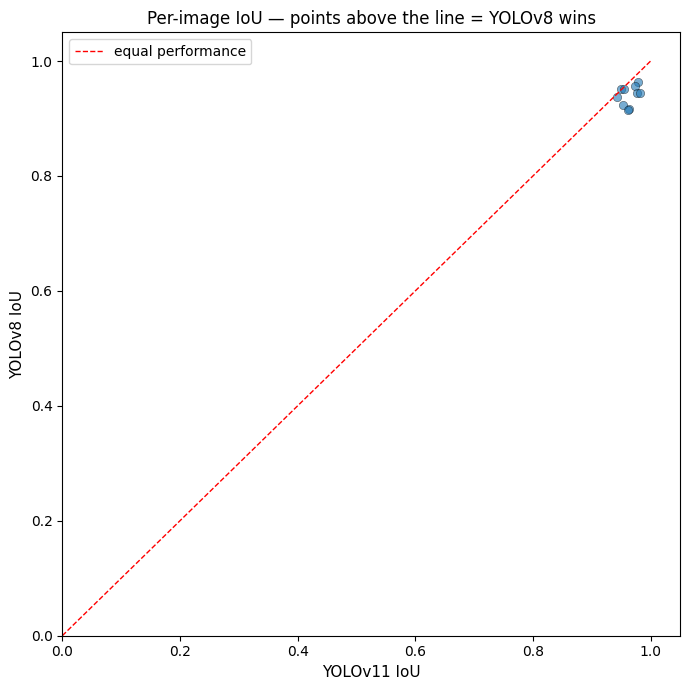

In [14]:
def compute_iou(a: list, b: list) -> float:
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter  = max(0, xB-xA) * max(0, yB-yA)
    areaA  = (a[2]-a[0]) * (a[3]-a[1])
    areaB  = (b[2]-b[0]) * (b[3]-b[1])
    union  = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def best_iou_for_image(model, img_path: Path, gt_boxes: list, conf: float = 0.25) -> float:
    """Return the highest IoU between any predicted box and any GT box."""
    preds = model.predict(str(img_path), conf=conf, verbose=False)[0].boxes
    if not preds or not gt_boxes:
        return 0.0
    best = 0.0
    for pred in preds:
        px = [int(v) for v in pred.xyxy[0].tolist()]
        for gt in gt_boxes:
            best = max(best, compute_iou(px, gt))
    return best


# ── Compute per-image IoU for both models ─────────────────────────────────────
records = []
for img_p in all_val_imgs:
    lbl_p = val_lbl_dir / img_p.with_suffix(".txt").name
    img   = cv2.imread(str(img_p))
    if img is None:
        continue
    h, w  = img.shape[:2]
    gts   = parse_gt_boxes(lbl_p, w, h)
    if not gts:
        continue
    records.append({
        "image":     img_p.name,
        "my_iou":    best_iou_for_image(my_model,  img_p, gts),
        "ref_iou":   best_iou_for_image(ref_model, img_p, gts),
    })

df_iou = pd.DataFrame(records)
print(f"Images with GT labels: {len(df_iou)}")
print(f"\nMean IoU — YOLOv8  : {df_iou['my_iou'].mean():.4f}")
print(f"Mean IoU — YOLOv11 : {df_iou['ref_iou'].mean():.4f}")

# ── Scatter plot: YOLOv8 IoU vs YOLOv11 IoU per image ────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df_iou["ref_iou"], df_iou["my_iou"], alpha=0.6, edgecolors="k", linewidths=0.4)
ax.plot([0,1],[0,1], "r--", linewidth=1, label="equal performance")
ax.set_xlabel("YOLOv11 IoU", fontsize=11)
ax.set_ylabel("YOLOv8 IoU", fontsize=11)
ax.set_title("Per-image IoU — points above the line = YOLOv8 wins")
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Summary Verdict


In [15]:
# ── Print a human-readable verdict ───────────────────────────────────────────
my  = df_metrics.loc["YOLOv8"]
ref = df_metrics.loc["YOLOv11"]

print("=" * 55)
print("  COMPARISON SUMMARY")
print("=" * 55)

categories = {
    "mAP@50":    (my["mAP@50"],    ref["mAP@50"],    "higher = better"),
    "mAP@50:95": (my["mAP@50:95"], ref["mAP@50:95"], "higher = better"),
    "Precision":  (my["Precision"],  ref["Precision"],  "higher = better"),
    "Recall":     (my["Recall"],     ref["Recall"],     "higher = better"),
    "Mean IoU":  (df_iou["my_iou"].mean(), df_iou["ref_iou"].mean(), "higher = better"),
}

yolo8_wins = yolo11_wins = ties = 0
for name, (my_val, ref_val, note) in categories.items():
    diff   = my_val - ref_val
    winner = "YOLOv8 ✓" if diff > 0.002 else ("YOLOv11 ✓" if diff < -0.002 else "TIE")
    if "YOLOv8"  in winner: yolo8_wins  += 1
    elif "YOLOv11" in winner: yolo11_wins += 1
    else: ties += 1
    print(f"  {name:<14}  YOLOv8:{my_val:.4f}  YOLOv11:{ref_val:.4f}  Δ:{diff:+.4f}  → {winner}")

print("-" * 55)
print(f"  YOLOv8 wins: {yolo8_wins}  |  YOLOv11 wins: {yolo11_wins}  |  Ties: {ties}")
print("=" * 55)

if yolo8_wins > yolo11_wins:
    print("\n  ► YOLOv8 outperforms YOLOv11 on this dataset.")
elif yolo11_wins > yolo8_wins:
    print("\n  ► YOLOv11 outperforms YOLOv8 on this dataset.")
else:
    print("\n  ► Roughly equal — both models perform on par.")


  COMPARISON SUMMARY
  mAP@50          YOLOv8:0.0000  YOLOv11:0.0000  Δ:+0.0000  → TIE
  mAP@50:95       YOLOv8:0.0000  YOLOv11:0.0000  Δ:+0.0000  → TIE
  Precision       YOLOv8:0.0000  YOLOv11:0.0000  Δ:+0.0000  → TIE
  Recall          YOLOv8:0.0000  YOLOv11:0.0000  Δ:+0.0000  → TIE
  Mean IoU        YOLOv8:0.9405  YOLOv11:0.9633  Δ:-0.0228  → YOLOv11 ✓
-------------------------------------------------------
  YOLOv8 wins: 0  |  YOLOv11 wins: 1  |  Ties: 4

  ► YOLOv11 outperforms YOLOv8 on this dataset.
